In [1]:
# imports
import numpy as np
import pandas as pd
import scipy as sp
from typing import Callable, Optional, List, Self
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_predict, KFold

In [24]:
import seaborn as sns

In [2]:
def CosineKernel( vU: np.ndarray ) -> np.ndarray:
    return (np.abs(vU) < 1) * (1 + np.cos(np.pi * vU))

def GaussianKernel( vU: np.ndarray ) -> np.ndarray:
    return np.exp(-0.5 * np.square(vU))

def TriangularKernel( vU: np.ndarray ) -> np.ndarray:
    return (np.abs(vU) < 1) * (1 - np.abs(vU))

def UniformKernel( vU: np.ndarray ) -> np.ndarray:
    return 1 * (np.abs(vU) < 0.5)

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

dfX = df.drop(columns="medv")
dsY = df["medv"]

print(f"The features data shape: {dfX.shape}")
print(f"The labels data shape: {dsY.shape}")

The features data shape: (506, 13)
The labels data shape: (506,)


In [4]:
#creation of feature and target matrix
mX = dfX.drop(columns=['chas', 'rad']).to_numpy()
vY = dsY.to_numpy()

print(mX.shape)
print(vY.shape)

(506, 11)
(506,)


In [5]:
oStdScaler = StandardScaler()
mX = oStdScaler.fit_transform(mX)

In [11]:
mX.shape

(506, 11)

In [12]:
vY.shape

(506,)

In [13]:
mX.shape[0] == vY.shape[0]

True

In [6]:
# Parameters

lKernelType = ['Cosine', 'Gaussian', 'Triangular', 'Uniform']
#===========================Fill This===========================#
# 1. Set the range of values of `h` (Bandwidth).
lH          = list(np.linspace(0.1, 5, 50))
#===============================================================#

lKernels = [('Cosine', CosineKernel), ('Gaussian', GaussianKernel), ('Triangular', TriangularKernel), ('Uniform', UniformKernel)]

# Data Visualization
gridNoiseStd = 0.05
numGridPts = 250

In [7]:
# We build a function which apply kernel regression and predict the values of target

def ApplyKernelRegression(hKernel: Callable[[NDArray], NDArray], paramH: float, mX:NDArray, vY: NDArray, mX0:NDArray, metricType: str = 'euclidean', zeroThr:float=1e-9) -> NDArray:

    if paramH <= 0:
        raise ValueError('paramH must be positive')
    mD = sp.spatial.distance.cdist(mX0, mX, metric=metricType) # matrix of disatnces between every row in matrox mX0 to every row in matrix mX
    mW = hKernel(mD / paramH) # calculation of weights with kernel function and paramH (channel width)
    vK = mW @ vY 
    vW = np.sum(mW, axis=1) # Summation of every row for further normalization
    vI = np.abs(vW) < zeroThr # finding of indexes with values which a close to zero, to evoid devision by zero 
    vK[vI] = 0.0 # asigning of zero to indexes which where very close to zero
    vW[vI] = 1.0 # by assigning of value 1 to vW[vI] we devide 0/1 and get zero and by this way avoiding deviding by zero
    vYPred = vK / vW

    return vYPred

In [16]:
# Creation of SciKit Estimator

class KernelRegressor(RegressorMixin, BaseEstimator):
    def __init__(self, kernelType: str = 'Gaussian', paramH: Optional[float] = None, metricType: str = 'euclidean', lKernels: List = lKernels):
        self.kernelType = kernelType
        hKernel = None
        for tKernel in lKernels:
            if tKernel[0] == kernelType:
                hKernel = tKernel[1]
                break
        if hKernel is not None:
            self.hKernel = hKernel
        else:
            raise ValueError(f'The kernel in kernelType = {kernelType} is not in lKernels')
        self.paramH = paramH
        self.metricType = metricType
        self.lKernels = lKernels

    def fit(self, mX:NDArray, vY:NDArray) -> Self:
        
        if np.ndim(mX) != 2:
            raise ValueError(f'The input mX must be an array like of size (n_samples, n_features) !')
        if mX.shape[0] != vY.shape[0]:
            raise ValueError(f'vY must be vector with target values for n_sampes in mX')
        
        numSamples = mX.shape[0]
        if self.paramH is None:
            σ = np.sqrt(np.sum(np.sqaure(mX - np.mean(mX, axis = 0))))
            self.paramH = 1.06 * σ * (numSamples ** (-0.2))
        self.mXd = mX.copy()
        self.vYd = vY.copy()

        return self
    
    def predict(self, mX:NDArray) -> NDArray:
        if np.ndim(mX) != 2:
            raise ValueError(f'The input mX must be an array like of size (n_samples, n_features) !')
        if mX.shape[1] != self.mXd.shape[1]:
            raise ValueError(f'The input `mX` must be an array like of size (n_samples, n_features) where `n_features` matches the number of feature in `fit()` !')
        
        return ApplyKernelRegression(hKernel=self.hKernel, paramH=self.paramH, mX=self.mXd, vY=self.vYd, mX0=mX, metricType=self.metricType)
    
    def score(self, mX: NDArray, vY: NDArray) -> float:
        # return R2 as a score
        if (np.size(vY) != np.size(mX, axis = 0)):
            raise ValueError(f'The number of samples in `mX` must match the number of labels in `vY`.')
        
        vYPred = self.predic(mX)
        valR2 = r2_score(vY, vYPred)
        return valR2
       


In [40]:
numComb = len(lKernelType) * len(lH)
dData = {
    'Kernel Type': [],
    'h' : [],
    'R2': [0.0] * numComb
} # creation of dictionary

for ii, kernelType in enumerate(lKernelType):
    for jj, paramH in enumerate(lH):
        dData['Kernel Type'].append(kernelType)
        dData['h'].append(paramH)

dfModelScore = pd.DataFrame(data=dData)
dfModelScore

,Kernel Type,h,R2
0,Cosine,0.1,0.0
1,Cosine,0.2,0.0
2,Cosine,0.3,0.0
3,Cosine,0.4,0.0
4,Cosine,0.5,0.0
...,...,...,...
195,Uniform,4.6,0.0
196,Uniform,4.7,0.0
197,Uniform,4.8,0.0
198,Uniform,4.9,0.0


In [41]:
# Optimize the model

for ii in range(numComb):
    kernelType = dfModelScore.loc[ii, 'Kernel Type']
    paramH = dfModelScore.loc[ii, 'h']

    print(f'Processing model {ii + 1:03d} out of {numComb} with Kernel Type = {kernelType} and h = {paramH}.')

    oKerReg = KernelRegressor(kernelType=kernelType, paramH=paramH)
    vYPred = cross_val_predict(oKerReg, mX, vY, cv = KFold(n_splits=mX.shape[0]))
    scoreR2 = r2_score(vY, vYPred)
    dfModelScore.loc[ii, 'R2'] = scoreR2
    print(f'Finishing processing model {ii +1} withR2 = {scoreR2}')

Processing model 001 out of 200 with Kernel Type = Cosine and h = 0.1.
Finishing processing model 1 withR2 = -6.0143334549242375
Processing model 002 out of 200 with Kernel Type = Cosine and h = 0.2.
Finishing processing model 2 withR2 = -5.898468304355499
Processing model 003 out of 200 with Kernel Type = Cosine and h = 0.30000000000000004.
Finishing processing model 3 withR2 = -5.402402023350156
Processing model 004 out of 200 with Kernel Type = Cosine and h = 0.4.
Finishing processing model 4 withR2 = -4.819033290318893
Processing model 005 out of 200 with Kernel Type = Cosine and h = 0.5.
Finishing processing model 5 withR2 = -3.819378548516875
Processing model 006 out of 200 with Kernel Type = Cosine and h = 0.6.
Finishing processing model 6 withR2 = -2.8635178640088883
Processing model 007 out of 200 with Kernel Type = Cosine and h = 0.7000000000000001.
Finishing processing model 7 withR2 = -1.8961825999101731
Processing model 008 out of 200 with Kernel Type = Cosine and h = 0.8.

In [42]:
dfModelScore['h'] = dfModelScore['h'].round(3)
dfModelScore = dfModelScore.sort_values(by='R2', ascending=False).head(50)                        

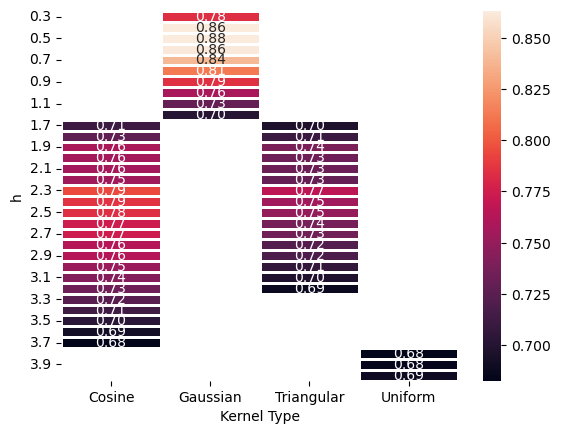

In [43]:
hF, hA = plt.subplots()
hA = sns.heatmap(data= dfModelScore.pivot(index= 'h', columns='Kernel Type', values='R2'), robust=True, linewidths=1, annot=True, fmt = '0.2f', ax=hA)

In [45]:
bestModelIdx = dfModelScore['R2'].idxmax()
bestModelIdx

np.int64(54)

In [46]:
kernelType = dfModelScore.loc[bestModelIdx, 'Kernel Type']
paramH = dfModelScore.loc[bestModelIdx, 'h']

In [47]:
oKerReg = KernelRegressor(kernelType=kernelType, paramH=paramH).fit(mX, vY)

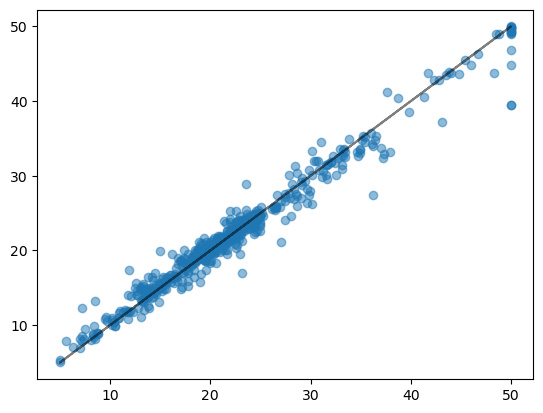

In [50]:
_, ax = plt.subplots()

ax.scatter(vY, oKerReg.predict(mX), alpha=0.5)
ax.plot(vY, vY, color='k', alpha=0.5)
plt.show()

In [52]:
dfData = pd.concat([dfX, dsY], axis = 1)

In [53]:
# Build the Data Frame for Analysis per Feature
featureName001 = 'crim'
featureName002 = 'tax'

featureName001 = 'zn'
featureName002 = 'nox'

featureName001 = 'age'
featureName002 = 'ptratio'

dfFeatAnl = pd.DataFrame(data = {featureName001: dfData[featureName001], featureName002: dfX[featureName002], 'True Price': vY, 'Predicted Price': oKerReg.predict(mX), 'AbsError': np.abs(vY - oKerReg.predict(mX))})
dfFeatAnl


,age,ptratio,True Price,Predicted Price,AbsError
0,65.2,15.3,24.0,24.478200,0.478200
1,78.9,17.8,21.6,23.620001,2.020001
2,61.1,17.8,34.7,32.606481,2.093519
3,45.8,18.7,33.4,33.253533,0.146467
4,54.2,18.7,36.2,33.992162,2.207838
...,...,...,...,...,...
501,69.1,21.0,22.4,21.595504,0.804496
502,76.7,21.0,20.6,18.271445,2.328555
503,91.0,21.0,23.9,23.036393,0.863607
504,89.3,21.0,22.0,22.584393,0.584393


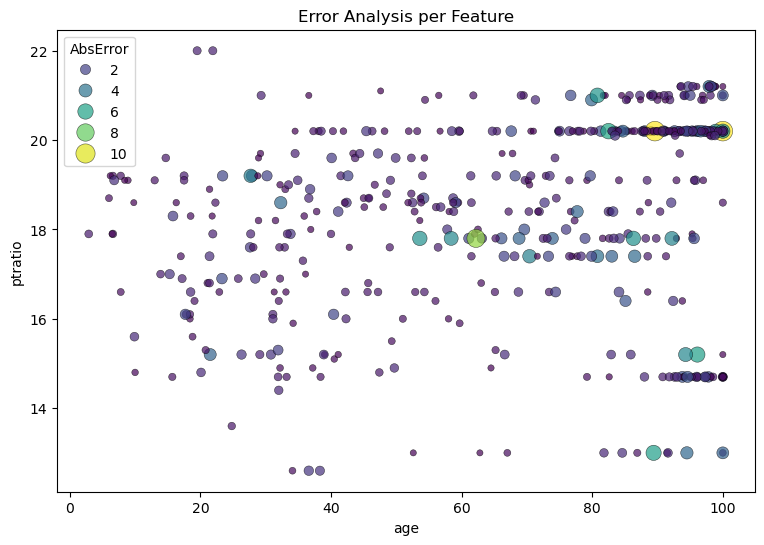

In [54]:
hF, hA = plt.subplots(figsize = (9, 6))
sns.scatterplot(data = dfFeatAnl, x = featureName001, y = featureName002, size = 'AbsError', hue = 'AbsError', palette = 'viridis', sizes = (20, 200), alpha = 0.7, edgecolor = 'k', ax = hA)
hA.set_title('Error Analysis per Feature');

In [55]:
numSamples = len(vY) #<! Number of Samples
hK = GaussianKernel #<! Kernel
paramH = 0.3 #<! Bandwidth
mD = sp.spatial.distance.cdist(mX, mX, metric = 'euclidean') #<! Distance Matrix
mW = hK(mD / paramH) #<! Weights matrix

# Zeroing the diagonal to prevent the weight of the sample
mW[range(numSamples), range(numSamples)] = 0 #<! Leave One Out
vYPred = (mW @ vY) / np.sum(mW, axis = 1) #<! Kernel Regression

print(f'The Leave One Out R2 Score for Kernel Type = {hK} and Bandwidth = {paramH} is {r2_score(vY, vYPred) }.')

The Leave One Out R2 Score for Kernel Type = <function GaussianKernel at 0x000001F7E1AADB20> and Bandwidth = 0.3 is 0.8861968191595648.
